<a href="https://colab.research.google.com/github/imginnychoi-08/Data-Trends-in-In-Person-vs-Online-Physical-Therapies/blob/main/Trend%20Lines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
import pandas as pd

# Load the CSV file (header=None since the file does not contain column headers)
df = pd.read_csv('combined_output.csv', header=None)

# Optionally, you can name the columns for easier reference:
# df.columns = ['Provider_Type', 'Code', 'Value_1', 'Value_2']

# View the first few rows
print(df.head())

# View basic information about the dataset
print(df.info())

                                        0  1    2   3
0  Physical Therapist in Private Practice  O  163  20
1  Physical Therapist in Private Practice  O  511  20
2  Physical Therapist in Private Practice  O  397  20
3  Physical Therapist in Private Practice  O   52  20
4  Physical Therapist in Private Practice  O   17  20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797780 entries, 0 to 1797779
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   0       object
 1   1       object
 2   2       int64 
 3   3       int64 
dtypes: int64(2), object(2)
memory usage: 54.9+ MB
None


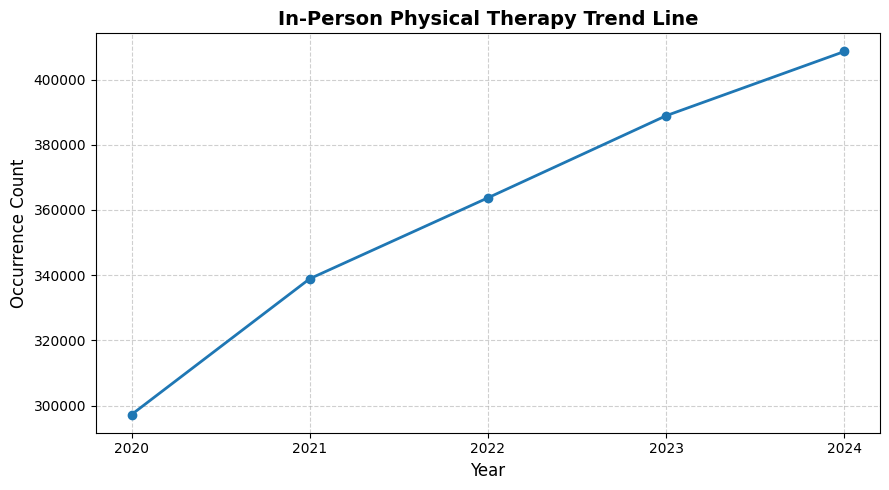

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_one():
    df = pd.read_csv("PHY_R26_P05_V10_D24_Prov_Svc.csv")
    df = df[['Rndrng_Prvdr_Type', 'Place_Of_Srvc', 'Tot_Bene_Day_Srvcs']]

    mask = df.astype(str).apply(
        lambda col: col.str.contains("Physical Therapist", case=False, na=False)
    ).any(axis=1)

    # Filter the DataFrame
    df_pt = df[mask]
    df_pt.to_csv("filtered_therapy_claims_test.csv", index=False)

def parse_many():
    # 1. Get a list of all matching CSV files in your folder
    file_paths = [("MUP_PHY_R25_P05_V20_D20_Prov_Svc.csv", 20), ("MUP_PHY_R25_P05_V20_D21_Prov_Svc.csv", 21), ("MUP_PHY_R25_P05_V20_D22_Prov_Svc.csv", 22), ("MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv", 23), ("PHY_R26_P05_V10_D24_Prov_Svc.csv", 24)]

    # 2. Read each file, add the file label column, and store in a list
    dfs = []
    for file, year in file_paths:
        print(file)
        print(year)
        temp_df = pd.read_csv(file)

        # Label with just the file name (e.g., 'data_2023.csv')
        temp_df['year'] = year
        temp_df = temp_df[['Rndrng_Prvdr_Type', 'Place_Of_Srvc', 'Tot_Bene_Day_Srvcs', 'year']]

        mask = temp_df.astype(str).apply(
            lambda col: col.str.contains("Physical Therapist", case=False, na=False)
        ).any(axis=1)
        temp_df = temp_df[mask]
        dfs.append(temp_df)

    # 3. Concatenate all DataFrames together
    combined_df = pd.concat(dfs, ignore_index=True)

    # 4. Save to a new CSV file WITHOUT headers
    combined_df.to_csv("combined_output.csv", header=False, index=False)


def to_graph():
    # 1. Read CSV (use header=None if your CSV lacks column names)
    headers = ['Occupation', 'Category', 'ID_Code', 'Year']
    df = pd.read_csv('combined_output.csv', names=headers)

    # 2. Filter for rows where Category is 'O'
    df_o = df[df['Category'] == 'O']

    # 3. Count occurrences of "O" for each year (ignores column 3 entirely)
    yearly_counts = df_o.groupby('Year').size().reset_index(name='Frequency')

    # Optional: Convert 2-digit years (e.g., 20) to 4-digit years (e.g., 2020)
    yearly_counts['Year'] = pd.to_datetime(yearly_counts['Year'].astype(str), format='%y').dt.year

    # 4. Plot the results
    plt.figure(figsize=(9, 5))
    plt.plot(
        yearly_counts['Year'],
        yearly_counts['Frequency'],
        marker='o',
        color='#1f77b4',
        linewidth=2
    )

    plt.title('In-Person Physical Therapy Trend Line', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Occurrence Count', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(yearly_counts['Year'])

    plt.tight_layout()
    plt.savefig('online.png')
    plt.show()


# parse_one() # Commented out as it depends on external files
# parse_many() # Commented out as it depends on external files
to_graph()